# DWAI

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [3]:
train_df = pd.read_csv(
  "data/preprocessed/train.tsv", 
  sep="\t", 
  header=None, 
  names=["text", "emotion_ids", "id"]
)
train_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [4]:
print(train_df.columns)

Index(['text', 'emotion_ids', 'id'], dtype='str')


In [5]:
print(train_df.shape)

(43410, 3)


In [7]:
train_df['emotion_ids'].value_counts()

emotion_ids
27            12823
0              2710
4              1873
15             1857
1              1652
              ...  
0,12,13,26        1
1,2,5,17          1
13,14             1
3,9,12            1
0,1,18            1
Name: count, Length: 711, dtype: int64

In [8]:
train_df['emotion_ids'].value_counts().head(10)

emotion_ids
27    12823
0      2710
4      1873
15     1857
1      1652
3      1451
18     1427
10     1402
7      1389
2      1025
Name: count, dtype: int64

In [9]:
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness",
    "surprise", "neutral"
]

for i, emotion in enumerate(emotion_labels):
  print(i, emotion)

0 admiration
1 amusement
2 anger
3 annoyance
4 approval
5 caring
6 confusion
7 curiosity
8 desire
9 disappointment
10 disapproval
11 disgust
12 embarrassment
13 excitement
14 fear
15 gratitude
16 grief
17 joy
18 love
19 nervousness
20 optimism
21 pride
22 realization
23 relief
24 remorse
25 sadness
26 surprise
27 neutral


In [10]:
train_df['emotion_ids'].nunique()

711

In [12]:
train_df['emotion_ids'].unique()[:30]

<ArrowStringArray>
[    '27',      '2',     '14',      '3',     '26',     '15',   '8,20',
      '0',      '6',    '1,4',      '5',   '3,12',   '6,22', '6,9,27',
     '12',  '16,25',    '2,7',     '17',     '25',   '0,15',  '15,18',
  '16,27',   '7,13',     '10',     '20',      '4',  '13,15',    '0,1',
     '13',      '1']
Length: 30, dtype: str

In [13]:
train_df['emotion_ids'].str.contains(',').value_counts()

emotion_ids
False    36308
True      7102
Name: count, dtype: int64

In [14]:
train_df['emotion_ids'].str.contains(',')

0        False
1        False
2        False
3        False
4        False
         ...  
43405    False
43406    False
43407    False
43408    False
43409    False
Name: emotion_ids, Length: 43410, dtype: bool

In [15]:
train_df['emotion_ids'].str.contains(',').sum()

np.int64(7102)

In [16]:
total_count = len(train_df)
multi_labeled_count = train_df['emotion_ids'].str.contains(',').sum()
single_labeled_count = (~train_df['emotion_ids'].str.contains(',')).sum()

print(f"Total data points: {total_count}")
print(f"Single-labeled data points: {single_labeled_count}")
print(f"Multi-labeled data points: {multi_labeled_count}")

Total data points: 43410
Single-labeled data points: 36308
Multi-labeled data points: 7102


## Single-Labeled Data

In [17]:
single_labeled_df = train_df[
  ~(train_df['emotion_ids'].str.contains(','))
].copy()

In [18]:
single_labeled_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [19]:
single_labeled_df.shape

(36308, 3)

In [20]:
single_labeled_df['emotion_ids'] = single_labeled_df['emotion_ids'].astype(int)
single_labeled_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [21]:
single_labeled_df['emotion_ids']

0        27
1        27
2         2
3        14
4         3
         ..
43405    18
43406     6
43407     3
43408    13
43409    17
Name: emotion_ids, Length: 36308, dtype: int64

In [22]:
with open("data/preprocessed/emotions.txt") as f:
  emotion_labels = [line.strip() for line in f if line.strip()]

emotion_labels

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral']

In [23]:
emotion_mapping = dict(enumerate(emotion_labels))
emotion_mapping

{0: 'admiration',
 1: 'amusement',
 2: 'anger',
 3: 'annoyance',
 4: 'approval',
 5: 'caring',
 6: 'confusion',
 7: 'curiosity',
 8: 'desire',
 9: 'disappointment',
 10: 'disapproval',
 11: 'disgust',
 12: 'embarrassment',
 13: 'excitement',
 14: 'fear',
 15: 'gratitude',
 16: 'grief',
 17: 'joy',
 18: 'love',
 19: 'nervousness',
 20: 'optimism',
 21: 'pride',
 22: 'realization',
 23: 'relief',
 24: 'remorse',
 25: 'sadness',
 26: 'surprise',
 27: 'neutral'}

In [24]:
single_labeled_df['emotion'] = single_labeled_df['emotion_ids'].map(emotion_mapping)
single_labeled_df.head()

,text,emotion_ids,id,emotion
0,My favourite food is anything I didn't have to...,27,eebbqej,neutral
1,"Now if he does off himself, everyone will thin...",27,ed00q6i,neutral
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj,anger
3,To make her feel threatened,14,ed7ypvh,fear
4,Dirty Southern Wankers,3,ed0bdzj,annoyance


In [25]:
class_distribution = single_labeled_df['emotion'].value_counts()
class_distribution

emotion
neutral           12823
admiration         2710
approval           1873
gratitude          1857
amusement          1652
annoyance          1451
love               1427
disapproval        1402
curiosity          1389
anger              1025
optimism            861
confusion           858
joy                 853
sadness             817
surprise            720
disappointment      709
caring              649
realization         586
excitement          510
disgust             498
fear                430
desire              389
remorse             353
embarrassment       203
relief               88
nervousness          85
pride                51
grief                39
Name: count, dtype: int64

In [26]:
print(f"Number of emotion classes: {single_labeled_df['emotion'].nunique()}")
print(f"Most common emotion: {class_distribution.index[0]} ({class_distribution.iloc[0]:,})")
print(f"Least common emotion: {class_distribution.index[-1]} ({class_distribution.iloc[-1]:,})")

Number of emotion classes: 28
Most common emotion: neutral (12,823)
Least common emotion: grief (39)


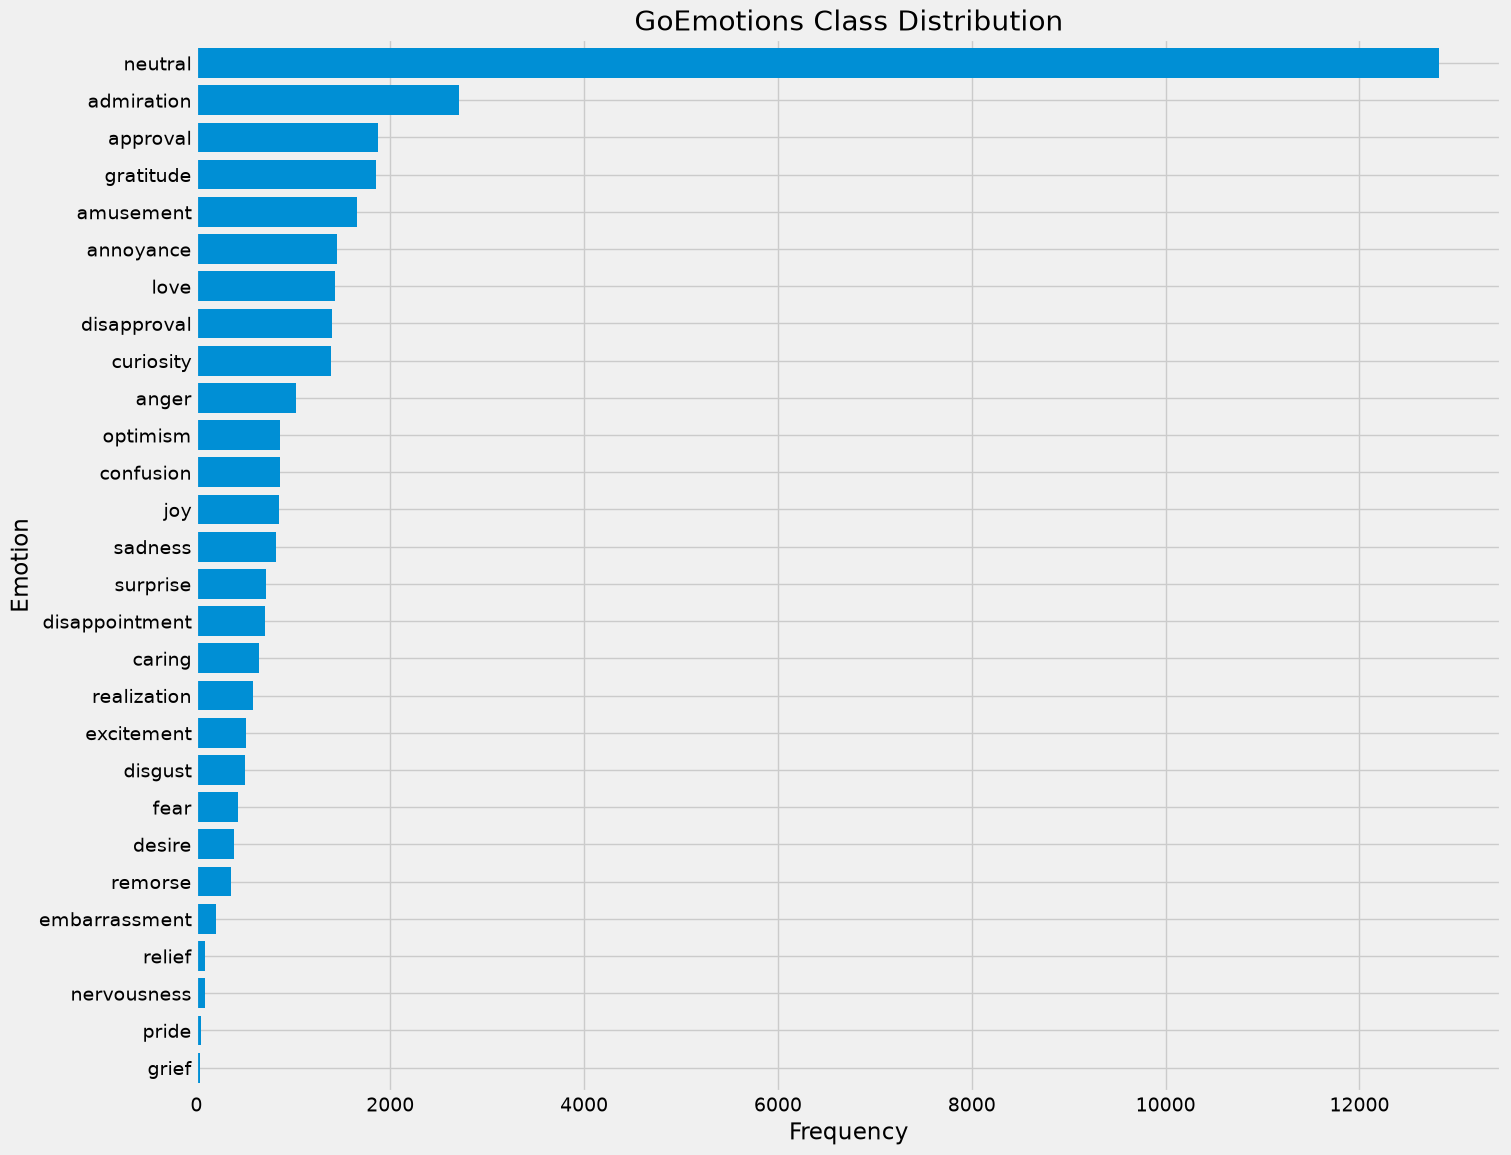

In [27]:
plt.style.use('fivethirtyeight')
class_distribution.sort_values().plot(
  kind="barh", 
  figsize=(15, 13), 
  width=0.8
)

plt.xlabel("Frequency")
plt.ylabel("Emotion")
plt.title("GoEmotions Class Distribution")
plt.show()

In [28]:
class_distribution.index

Index(['neutral', 'admiration', 'approval', 'gratitude', 'amusement',
       'annoyance', 'love', 'disapproval', 'curiosity', 'anger', 'optimism',
       'confusion', 'joy', 'sadness', 'surprise', 'disappointment', 'caring',
       'realization', 'excitement', 'disgust', 'fear', 'desire', 'remorse',
       'embarrassment', 'relief', 'nervousness', 'pride', 'grief'],
      dtype='str', name='emotion')

In [29]:
class_distribution.values

array([12823,  2710,  1873,  1857,  1652,  1451,  1427,  1402,  1389,
        1025,   861,   858,   853,   817,   720,   709,   649,   586,
         510,   498,   430,   389,   353,   203,    88,    85,    51,
          39])

In [30]:
single_labeled_df.head()

,text,emotion_ids,id,emotion
0,My favourite food is anything I didn't have to...,27,eebbqej,neutral
1,"Now if he does off himself, everyone will thin...",27,ed00q6i,neutral
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj,anger
3,To make her feel threatened,14,ed7ypvh,fear
4,Dirty Southern Wankers,3,ed0bdzj,annoyance


In [31]:
x = single_labeled_df['text']
x.head()

0    My favourite food is anything I didn't have to...
1    Now if he does off himself, everyone will thin...
2                       WHY THE FUCK IS BAYLESS ISOING
3                          To make her feel threatened
4                               Dirty Southern Wankers
Name: text, dtype: str

In [32]:
y = single_labeled_df['emotion']
y

0           neutral
1           neutral
2             anger
3              fear
4         annoyance
            ...    
43405          love
43406     confusion
43407     annoyance
43408    excitement
43409           joy
Name: emotion, Length: 36308, dtype: str

In [33]:
print(f'Features: {x.shape}')
print(f'Target: {y.shape}')

Features: (36308,)
Target: (36308,)


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_val, y_train, y_val = train_test_split(
  x, 
  y, 
  test_size=0.33, 
  random_state=42,
  stratify=y
)

In [36]:
print(f"Training Data: {len(X_train)}")
print(f"Validation Data: {len(X_val)}")

Training Data: 24326
Validation Data: 11982


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.preprocessing import LabelEncoder

In [38]:
label_encoder = LabelEncoder()

In [39]:
y_train

459        curiosity
23430      amusement
18493      gratitude
16724    disapproval
17768      gratitude
            ...     
13315          anger
25736        neutral
10516       approval
26792       approval
23429        neutral
Name: emotion, Length: 24326, dtype: str

In [ ]:
# "fit" scans all unique strings in y_train, sorts them (alphabetically), and assigns each one a sequential INTEGER starting at 0. So "admiration" → 0, "amusement" → 1, "anger" → 2, and so on through all 28 classes.
y_train_ids = label_encoder.fit_transform(y_train)

# "transform" immediately applies that new mapping to y_train, converting every string in the array into its assigned integer.
y_val_ids = label_encoder.transform(y_val)

print(dict(enumerate(label_encoder.classes_)))

{0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval', 5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment', 10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement', 14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love', 19: 'nervousness', 20: 'neutral', 21: 'optimism', 22: 'pride', 23: 'realization', 24: 'relief', 25: 'remorse', 26: 'sadness', 27: 'surprise'}


In [41]:
y_train_ids

array([ 7,  1, 15, ...,  4,  4, 20], shape=(24326,))

In [42]:
y_val_ids

array([20, 15, 20, ...,  6, 14, 20], shape=(11982,))

In [43]:
import sys 
print(sys.version)

3.14.4 (main, Apr  7 2026, 13:13:20) [Clang 21.0.0 (clang-2100.0.123.102)]


### BERT

In [44]:
import transformers
import torch 
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader 

/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [45]:
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Transformers: 5.17.0
PyTorch: 2.14.0


In [46]:
from transformers import BertTokenizer, BertForSequenceClassification

In [47]:
# This downloads the pretrained BERT tokenizer and its vocabulary.
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [48]:
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [49]:
text = "I hate this game"

tokens = tokenizer.tokenize(text)
print(tokens)

['i', 'hate', 'this', 'game']


In [50]:
# BERT converts strings into token IDs
token_ids = tokenizer.encode(text)
print(token_ids)

[101, 1045, 5223, 2023, 2208, 102]


In [51]:
X_train

459      I'm curious though, will they upvote it to own...
23430    i'm just making fun of how when moids say they...
18493                                      I will! Thanks!
16724    $11 an hour doesn't leave a lot of room to be ...
17768                                     Oh okay. Thanks.
                               ...                        
13315    Fuck it, maybe the faceless men worship the gr...
25736    I drive semi trucks into denver. Im not there ...
10516    Yeah you're right, I mistyped it. Should have ...
26792    Yes, he's really pushing the Devils to new hei...
23429                                    Resting cash face
Name: text, Length: 24326, dtype: str

In [52]:
sample = X_train[0]
sample

"My favourite food is anything I didn't have to cook myself."

In [53]:
encoded = tokenizer(
  sample, 
  padding="max_length", 
  truncation=True, 
  max_length=128
)

print(f"Text: {sample}")

print(f"Input IDs: {encoded["input_ids"]}")

print(f"Attention Mask: {encoded["attention_mask"]}")

Text: My favourite food is anything I didn't have to cook myself.
Input IDs: [101, 2026, 8837, 2833, 2003, 2505, 1045, 2134, 1005, 1056, 2031, 2000, 5660, 2870, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [54]:
# Tokenize entire datasets
train_encodings = tokenizer(
  list(X_train), 
  padding="max_length", 
  truncation=True, 
  max_length=128
)

val_encodings = tokenizer(
  list(X_val), 
  padding="max_length", 
  truncation=True, 
  max_length=128
)

In [55]:
print("Number of training examples:", len(train_encodings["input_ids"]))
print("Number of validation examples:", len(val_encodings["input_ids"]))

print("Training input shape:", len(train_encodings["input_ids"][0]))
print("Training mask shape:", len(train_encodings["attention_mask"][0]))

Number of training examples: 24326
Number of validation examples: 11982
Training input shape: 128
Training mask shape: 128


### Create PyTorch DataSet

* Creating a PyTorch Dataset that combines these BERT inputs with existing y_train_ids and y_val_ids.

In [56]:
class BertEmotionDataset(Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings 
    self.labels = torch.tensor(labels, dtype=torch.long)
    
  def __len__(self):
        return len(self.labels)
    
  def __getitem__(self, idx):
    return {
        "input_ids": torch.tensor(
            self.encodings["input_ids"][idx],
            dtype=torch.long
        ),
        "attention_mask": torch.tensor(
            self.encodings["attention_mask"][idx],
            dtype=torch.long
        ),
        "labels": self.labels[idx]
    }

In [57]:
train_dataset = BertEmotionDataset(
  train_encodings, 
  y_train_ids
)

val_dataset = BertEmotionDataset(
  val_encodings, 
  y_val_ids
)

In [58]:
train_dataset

In [59]:
sample = train_dataset[0]
sample

{'input_ids': tensor([  101,  1045,  1005,  1049,  8025,  2295,  1010,  2097,  2027,  2039,
         22994,  2063,  2009,  2000,  2219,  1996,  1066,  1066,  5622,  5910,
          1066,  1066,  1031,  2171,  1033,  1029,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,   

In [60]:
print(f"Input IDs shape: {sample["input_ids"].shape}")
print(f"Attention mask shape: {sample["attention_mask"].shape}")
print(f"Label: {sample["labels"]}")

Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Label: 7


In [61]:
train_loader = DataLoader(
  train_dataset, 
  batch_size=16, 
  shuffle=True
)

val_loader = DataLoader(
  val_dataset, 
  batch_size=16, 
  shuffle=False
)

In [62]:
batch = next(iter(train_loader))

print(f"Input ID Shape: {batch["input_ids"].shape}")
print(f"Attention Mask Shape: {batch["attention_mask"].shape}")
print(f"Labels Shape: {batch["labels"].shape}")

Input ID Shape: torch.Size([16, 128])
Attention Mask Shape: torch.Size([16, 128])
Labels Shape: torch.Size([16])


### Load BERT for Classification

In [64]:
model = BertForSequenceClassification.from_pretrained(
  "bert-base-uncased", 
  num_labels=28
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6568.56it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [65]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [66]:
# BERT Forward Pass 
batch = next(iter(train_loader))

outputs = model(
  input_ids=batch["input_ids"], 
  attention_mask=batch["attention_mask"], 
  labels=batch["labels"]
)

print("Logits shape:", outputs.logits.shape)
print("Loss:", outputs.loss.item())

Logits shape: torch.Size([16, 28])
Loss: 3.2422425746917725


In [67]:
# Optimizer
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

In [68]:
optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 2e-05
    maximize: False
    weight_decay: 0.01
)

In [69]:
import time

In [70]:
# # train for a few epochs
# tic = time.time()

# num_epochs = 3
# for epoch in range(num_epochs):
#   model.train()
  
#   total_loss = 0
  
#   for batch in train_loader:
#     # Clear gradients from previous batch.
#     optimizer.zero_grad()
    
#     # Forward pass
#     outputs = model(
#       input_ids=batch["input_ids"], 
#       attention_mask=batch["attention_mask"], 
#       labels=batch["labels"]
#     )
    
#     # BERT calculates CrossEntropyLoss for us.
#     loss = outputs.loss
    
#     # Backpropagation
#     loss.backward()
    
#     # Update model parameters.
#     optimizer.step()
    
#     total_loss += loss.item()
  
#   # Avg loss across all batches.
#   avg_loss = total_loss / len(train_loader)
  
#   print(
#         f"Epoch {epoch + 1}/{num_epochs} "
#         f"- Training Loss: {avg_loss:.4f}"
#     )
    
# toc = time.time()

# print('time:', round(toc-tic, 2),'s')

In [71]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [72]:
# model.eval()

# all_predictions = []
# all_labels = []

# with torch.no_grad():
#     for batch in val_loader:
#         outputs = model(
#             input_ids=batch["input_ids"],
#             attention_mask=batch["attention_mask"]
#         )

#         predictions = torch.argmax(outputs.logits, dim=1)

#         all_predictions.extend(predictions.cpu().numpy())
#         all_labels.extend(batch["labels"].cpu().numpy())

# accuracy = accuracy_score(all_labels, all_predictions)
# macro_f1 = f1_score(all_labels, all_predictions, average="macro")
# weighted_f1 = f1_score(all_labels, all_predictions, average="weighted")

# print(f"BERT Accuracy: {accuracy:.4f}")
# print(f"BERT Macro F1: {macro_f1:.4f}")
# print(f"BERT Weighted F1: {weighted_f1:.4f}")

In [73]:
# print(
#     classification_report(
#         all_labels,
#         all_predictions,
#         target_names=label_encoder.classes_,
#         zero_division=0
#     )
# )

## Load in BERT model

In [79]:
import torch 
import pickle

from transformers import BertTokenizer, BertForSequenceClassification

In [80]:
model_path = "./bert_goemotions_v1"

tokenizer = BertTokenizer.from_pretrained(model_path)

model = BertForSequenceClassification.from_pretrained(model_path)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15872.86it/s]


In [81]:
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [82]:
with open("./bert_goemotions_v1/label_encoder.pkl", "rb") as f:
  label_encoder = pickle.load(f)

In [83]:
# Test on a new sentence

text = "I absolutely love this game!"

inputs = tokenizer(
  text, 
  return_tensors="pt", 
  truncation=True, 
  max_length=128
)

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1)

emotion = label_encoder.inverse_transform(
    [prediction.item()]
)[0]

print("Prediction:", emotion)

Prediction: love


In [84]:
def predict_emotion(text, model, tokenizer, label_encoder, max_length=128):
  inputs = tokenizer(
    text, 
    return_tensors="pt", 
    truncation=True, 
    max_length=max_length
  )
  
  with torch.no_grad():
    outputs = model(**inputs)
  
  prediction = torch.argmax(outputs.logits, dim=1)

  emotion = label_encoder.inverse_transform(
      [prediction.item()]
  )[0]

  return emotion

In [85]:
print("Prediction:", predict_emotion("I absolutely love this game!", model, tokenizer, label_encoder))

Prediction: love


In [86]:
print("Prediction:", predict_emotion("I absolutely hate this game!", model, tokenizer, label_encoder))

Prediction: anger
